In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [99]:
# UN Refugee Data
asylum_data = pd.read_csv("/content/persons_of_concern.csv")

In [100]:
# UN M49 Data
un_data = pd.read_csv("/content/UN-M49.csv")

In [101]:
# Build a reference table keyed by ISO3
un_lookup = (
    un_data[[
        'ISO-alpha3 Code',
        'Region Name',
        'Sub-region Name',
        'Intermediate Region Name',
        'Least Developed Countries (LDC)',
        'Land Locked Developing Countries (LLDC)',
        'Small Island Developing States (SIDS)'
    ]]
    .rename(columns={
        'ISO-alpha3 Code': 'Country of Origin ISO',
        'Region Name': 'Origin Region Name',
        'Sub-region Name': 'Origin Sub-region Name',
        'Intermediate Region Name': 'Origin Intermediate Region Name',
        'Least Developed Countries (LDC)': 'Origin LDC',
        'Land Locked Developing Countries (LLDC)': 'Origin LLDC',
        'Small Island Developing States (SIDS)': 'Origin SIDS'
    })
    .drop_duplicates(subset=['Country of Origin ISO'])
)

In [102]:
# Filter US Data
us_asylum = asylum_data[asylum_data['Country of Asylum ISO'] == 'USA'].copy()

In [103]:
# Add M49 labels to US data
us_asylum = us_asylum.merge(
    un_lookup,
    how='left',
    on='Country of Origin ISO'
)

In [104]:
# eliminate country of asylum, country of asylum ISO
us_asylum = us_asylum.drop(columns=['Country of Asylum', 'Country of Asylum ISO'])

In [105]:
# Which origin ISO codes failed to match?
unmatched_iso = (
    us_asylum.loc[us_asylum['Origin Region Name'].isna(),
                           'Country of Origin ISO']
    .value_counts()
)
unmatched_iso.head(20)

,count
Country of Origin ISO,
UNK,75
XXA,27


In [106]:
def build_asylum_pivots(us_asylum):
    """
    Returns a dictionary of pivot tables for asylum seekers by year,
    disaggregated by different geographic levels.
    """

    column_map = {
        'region': 'Origin Region Name',
        'subregion': 'Origin Sub-region Name',
        'intermediate_region': 'Origin Intermediate Region Name'
    }

    pivots = {
        key: pd.pivot_table(
            us_asylum,
            index='Year',
            columns=col,
            values='Asylum-seekers',
            aggfunc='sum',
            fill_value=0
        )
        for key, col in column_map.items()
    }

    return pivots

In [107]:
# dictionary with geographic levels
asylum_pivots = build_asylum_pivots(us_asylum)

In [108]:
# geographic levels
asylum_pivots.keys()

dict_keys(['region', 'subregion', 'intermediate_region'])

In [109]:
# Asylum Seekers in the United States by Origin Region and Year
asylum_pivots['region'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 1988 to 2025
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Africa    38 non-null     int64
 1   Americas  38 non-null     int64
 2   Asia      38 non-null     int64
 3   Europe    38 non-null     int64
 4   Oceania   38 non-null     int64
dtypes: int64(5)
memory usage: 1.8 KB


In [110]:
asylum_pivots['subregion'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 1988 to 2025
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   Australia and New Zealand        38 non-null     int64
 1   Central Asia                     38 non-null     int64
 2   Eastern Asia                     38 non-null     int64
 3   Eastern Europe                   38 non-null     int64
 4   Latin America and the Caribbean  38 non-null     int64
 5   Melanesia                        38 non-null     int64
 6   Micronesia                       38 non-null     int64
 7   Northern Africa                  38 non-null     int64
 8   Northern America                 38 non-null     int64
 9   Northern Europe                  38 non-null     int64
 10  Polynesia                        38 non-null     int64
 11  South-eastern Asia               38 non-null     int64
 12  Southern Asia                    38 non-null     int

In [111]:
asylum_pivots['intermediate_region'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 1988 to 2025
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Caribbean        38 non-null     int64
 1   Central America  38 non-null     int64
 2   Eastern Africa   38 non-null     int64
 3   Middle Africa    38 non-null     int64
 4   South America    38 non-null     int64
 5   Southern Africa  38 non-null     int64
 6   Western Africa   38 non-null     int64
dtypes: int64(7)
memory usage: 2.4 KB


In [112]:
# region pivot
region_pivot = asylum_pivots['region']
# sort
region_totals = region_pivot.sum(axis=0)
sorted_regions = region_totals.sort_values(ascending=False).index
region_pivot_sorted = region_pivot[sorted_regions]

<Figure size 1400x700 with 0 Axes>

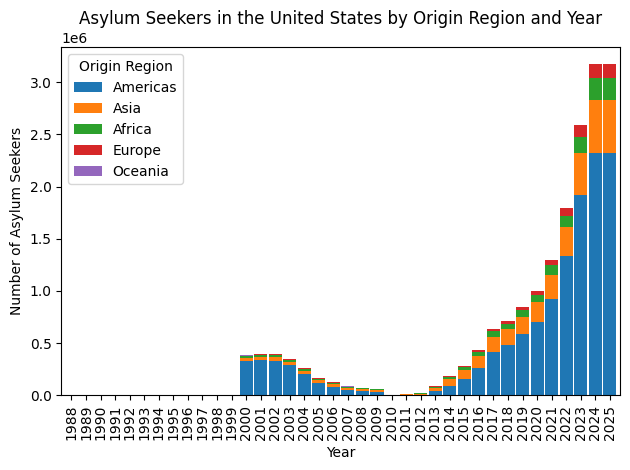

In [128]:
# Stacked Barchart of Asylum Seekers in the United States by Origin Region and Year

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

region_pivot_sorted.plot(
    kind='bar',
    stacked=True,
    width=0.9
)

plt.title('Asylum Seekers in the United States by Origin Region and Year')
plt.xlabel('Year')
plt.ylabel('Number of Asylum Seekers')

plt.legend(
    title='Origin Region',
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [114]:
# Filter Americas Origin Region
americas_asylum = us_asylum[us_asylum['Origin Region Name'] == 'Americas'].copy()
# Build intermediate_region pivot
americas_pivots = build_asylum_pivots(americas_asylum)
# sort
intermediate_region_pivot = americas_pivots['intermediate_region']
intermediate_region_totals = intermediate_region_pivot.sum(axis=0)
sorted_intermediate_regions = intermediate_region_totals.sort_values(ascending=False).index
intermediate_region_pivot_sorted = intermediate_region_pivot[sorted_intermediate_regions]

<Figure size 1400x700 with 0 Axes>

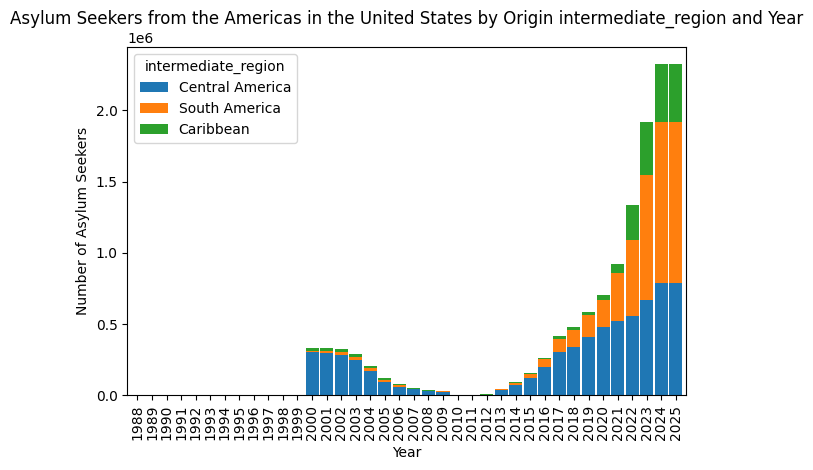

In [118]:
plt.figure(figsize=(14, 7))

intermediate_region_pivot_sorted.plot(
    kind='bar',
    stacked=True,
    width=0.9
)

plt.title('Asylum Seekers from the Americas in the United States by Origin intermediate_region and Year')
plt.xlabel('Year')
plt.ylabel('Number of Asylum Seekers')

plt.legend(
    title='intermediate_region',
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [137]:
# filter South America intermediate region
south_america_asylum = us_asylum[us_asylum['Origin Intermediate Region Name'] == 'South America'].copy()
# Count South American asylum seekers in the US per year and country of origin
south_america_pivot = pd.pivot_table(
            south_america_asylum,
            index='Year',
            columns='Country of Origin',
            values='Asylum-seekers',
            aggfunc='sum',
            fill_value=0
        )
# sort
country_totals = south_america_pivot.sum(axis=0)
top_5_countries = country_totals.sort_values(ascending=False).head(5).index

south_america_pivot_top5 = south_america_pivot[top_5_countries]
top5_totals = south_america_pivot_top5.sum(axis=0)

top5_sorted = top5_totals.sort_values(ascending=True).index
south_america_pivot_top5_sorted = south_america_pivot_top5[top5_sorted]
# filter
south_america_pivot_top5_2010_2025 = south_america_pivot_top5_sorted.loc[2010:2025]

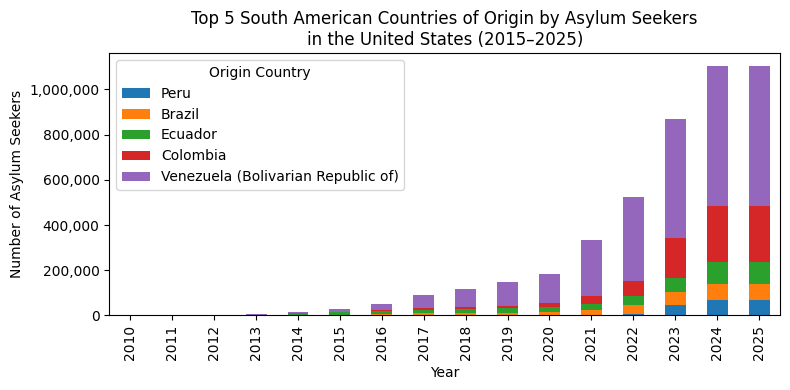

In [138]:

fig, ax = plt.subplots(figsize=(8, 4))

south_america_pivot_top5_2010_2025.plot(
    kind='bar',
    stacked=True,
    width=0.5,
    ax=ax
)

ax.set_title(
    'Top 5 South American Countries of Origin by Asylum Seekers\n'
    'in the United States (2015–2025)'
)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Asylum Seekers')

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax.legend(
    title='Origin Country',
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [139]:
# filter Central America intermediate region
central_america_asylum = us_asylum[us_asylum['Origin Intermediate Region Name'] == 'Central America'].copy()
# Count Central American asylum seekers in the US per year and country of origin
central_america_pivot = pd.pivot_table(
            central_america_asylum,
            index='Year',
            columns='Country of Origin',
            values='Asylum-seekers',
            aggfunc='sum',
            fill_value=0
        )
# sort
country_totals = central_america_pivot.sum(axis=0)
top_5_countries = country_totals.sort_values(ascending=False).head(5).index

central_america_pivot_top5 = central_america_pivot[top_5_countries]
top5_totals = central_america_pivot_top5.sum(axis=0)

top5_sorted = top5_totals.sort_values(ascending=True).index
central_america_pivot_top5_sorted = central_america_pivot_top5[top5_sorted]
# filter
central_america_pivot_top5_2010_2025 = central_america_pivot_top5_sorted.loc[2010:2025]

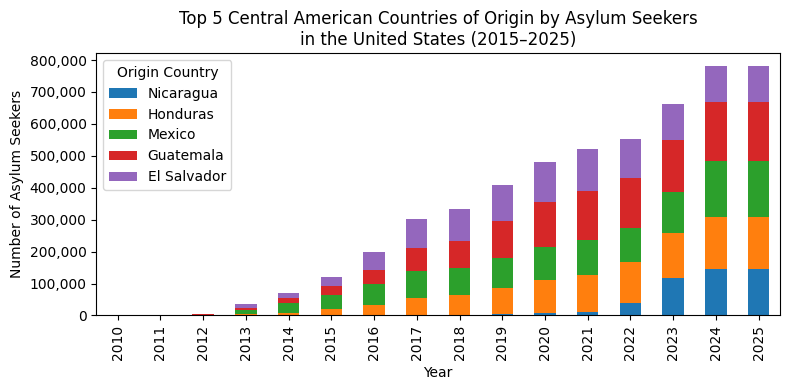

In [140]:

fig, ax = plt.subplots(figsize=(8, 4))

central_america_pivot_top5_2010_2025.plot(
    kind='bar',
    stacked=True,
    width=0.5,
    ax=ax
)

ax.set_title(
    'Top 5 Central American Countries of Origin by Asylum Seekers\n'
    'in the United States (2015–2025)'
)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Asylum Seekers')

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax.legend(
    title='Origin Country',
    loc='upper left'
)

plt.tight_layout()
plt.show()

In [141]:
# filter Caribbean intermediate region
caribbean_asylum = us_asylum[us_asylum['Origin Intermediate Region Name'] == 'Caribbean'].copy()
# Count Caribbean asylum seekers in the US per year and country of origin
caribbean_pivot = pd.pivot_table(
            caribbean_asylum,
            index='Year',
            columns='Country of Origin',
            values='Asylum-seekers',
            aggfunc='sum',
            fill_value=0
        )
# sort
country_totals = caribbean_pivot.sum(axis=0)
top_5_countries = country_totals.sort_values(ascending=False).head(5).index

caribbean_pivot_top5 = caribbean_pivot[top_5_countries]
top5_totals = caribbean_pivot_top5.sum(axis=0)

top5_sorted = top5_totals.sort_values(ascending=True).index
caribbean_pivot_top5_sorted = caribbean_pivot_top5[top5_sorted]
# filter
caribbean_pivot_top5_2010_2025 = caribbean_pivot_top5_sorted.loc[2010:2025]

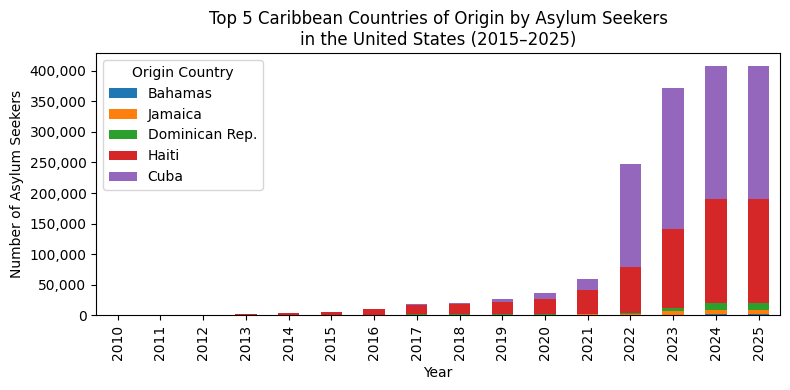

In [142]:

fig, ax = plt.subplots(figsize=(8, 4))

caribbean_pivot_top5_2010_2025.plot(
    kind='bar',
    stacked=True,
    width=0.5,
    ax=ax
)

ax.set_title(
    'Top 5 Caribbean Countries of Origin by Asylum Seekers\n'
    'in the United States (2015–2025)'
)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Asylum Seekers')

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax.legend(
    title='Origin Country',
    loc='upper left'
)

plt.tight_layout()
plt.show()